# EDA of dependent variables

## Code Status

In Progress (Expected to need updating upon receiving the full dataset)

## Purpose

Conduct EDA on both dependent variables (greatest apprehension & most
frequently used transportation method)

- Prepare tables/figures for memo on the distribution of dependent
  variables

- Elaborate on considerations for modelling informed by these findings

## Setup

In [ ]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

## EDA of apprehension scores

*Shape of both distributions*

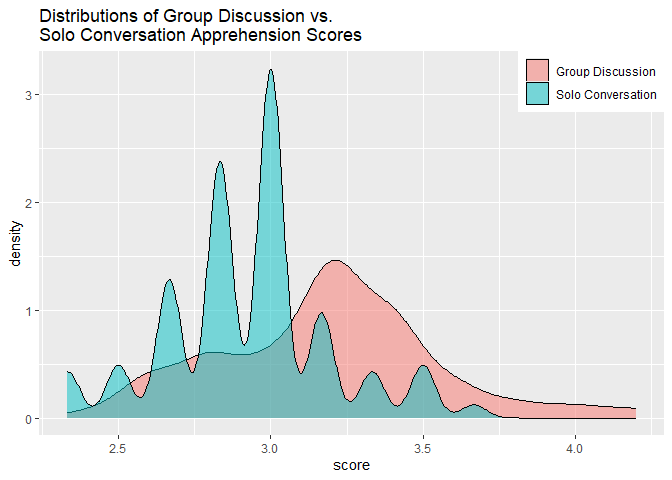

In [ ]:
survey_ap |>
  pivot_longer(
    cols = c(solo_apprehension, group_apprehension),
    names_to = "type",
    values_to = "score"
  ) |>
  ggplot(aes(x = score, fill = type)) +
  geom_density(alpha = 0.5) +
  scale_fill_discrete(
    labels = c(
      "group_apprehension" = "Group Discussion",
      "solo_apprehension"  = "Solo Conversation"
    )
  ) +
  labs(
    title = 'Distributions of Group Discussion vs.\nSolo Conversation Apprehension Scores',
    fill = NULL
  ) +
  theme(
    legend.position = "inside",
    legend.position.inside = c(1, 1),
    legend.justification = c(1, 1)
  )

`geom_smooth()` using formula = 'y ~ x'

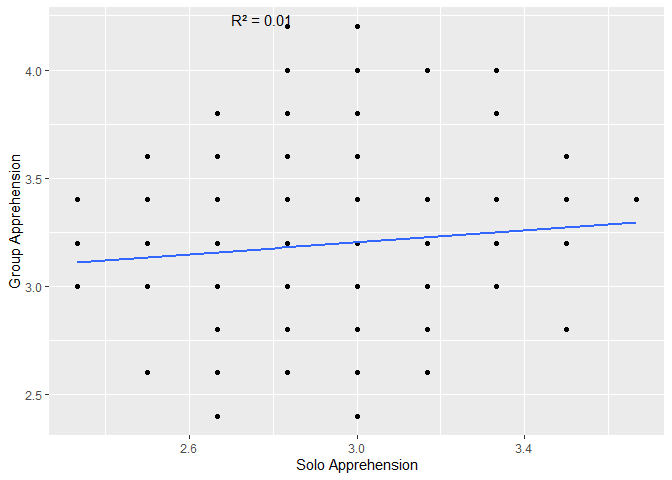

In [ ]:
r2 <- summary(lm(group_apprehension ~ solo_apprehension, data = survey_ap))$r.squared

ggplot(survey_ap, aes(x = solo_apprehension, y = group_apprehension)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  annotate("text", x = Inf, y = Inf, hjust = 7.1, vjust = 1.5,
           label = paste0("R\u00b2 = ", round(r2, 2))) +
  labs(
    x = "Solo Apprehension",
    y = "Group Apprehension"
  )

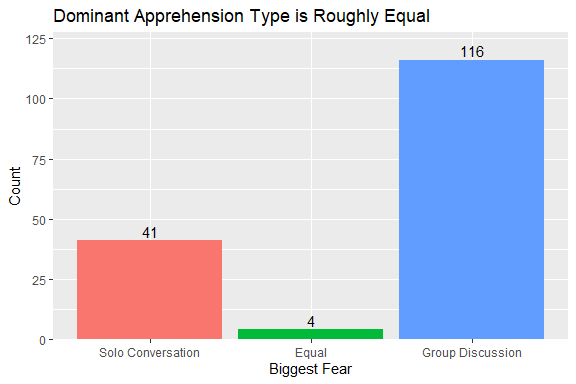

In [ ]:
#| label: dominant_apprehension_bar
#| fig-width: 6
#| fig-height: 4
#| out-width: 25%
survey_ap |>
  mutate(biggest_fear = biggest_fear |>
           replace_na("NA") |>
           factor(levels = c("solo_apprehension", "equal", "group_apprehension"))) |>
  ggplot(aes(x = biggest_fear, fill = biggest_fear)) +
  geom_bar() +
  geom_text(stat = "count", aes(label = after_stat(count)), vjust = -0.3) +
  scale_x_discrete(
    labels = c(
      "solo_apprehension"  = "Solo Conversation",
      "group_apprehension" = "Group Discussion",
      "equal"                 = "Equal"
    )
  ) +
  scale_fill_discrete(guide = "none") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  labs(
    title = 'Dominant Apprehension Type is Roughly Equal',
    x = "Biggest Fear",
    y = "Count"
  )

## EDA of transportation scores

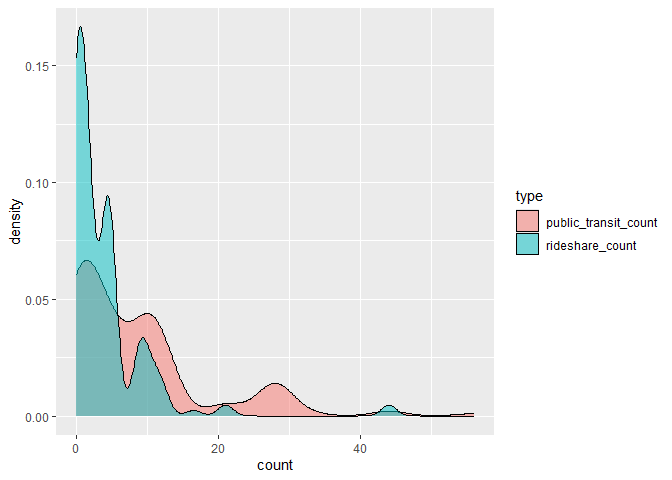

In [ ]:
survey_ts |>
  pivot_longer(
    cols = c(rideshare_count, public_transit_count),
    names_to = "type",
    values_to = "count"
  ) |>
  ggplot(aes(x = count, fill = type)) +
  geom_density(alpha = 0.5)

`geom_smooth()` using formula = 'y ~ x'

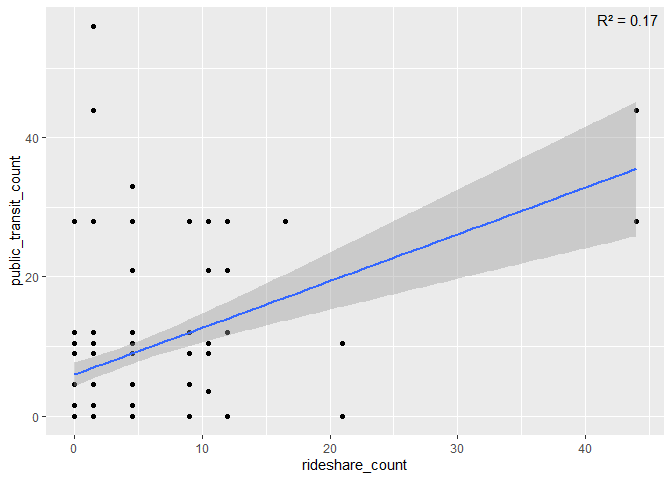

In [ ]:
r2 <- summary(lm(rideshare_count ~ public_transit_count, data = survey_ts))$r.squared

ggplot(survey_ts, aes(x = rideshare_count, y = public_transit_count)) +
  geom_point() +
  geom_smooth(method = "lm") +
  annotate("text", x = Inf, y = Inf, hjust = 1.1, vjust = 1.5,
           label = paste0("R\u00b2 = ", round(r2, 2)))

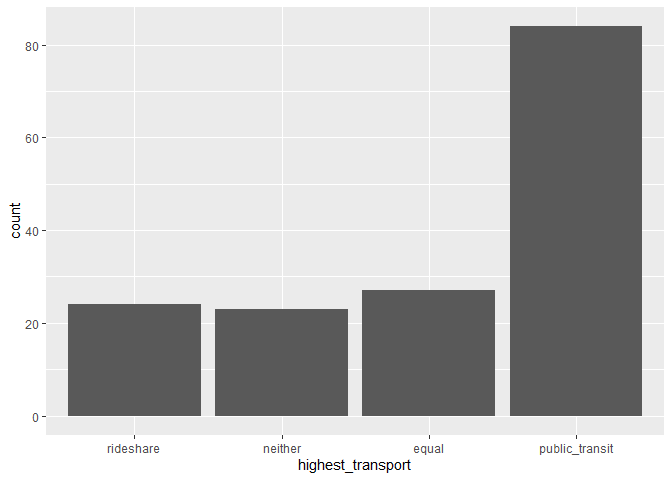

In [ ]:
survey_ts |>
  mutate(highest_transport = highest_transport |>
           replace_na("NA") |>
           factor(levels = c("rideshare", "neither", 'equal', "public_transit"))) |>
  ggplot(aes(x = highest_transport)) +
  geom_bar()

In [ ]:
#| label: dominant_transportation_bar
#| fig-width: 6
#| fig-height: 4
#| out-width: 25%
p_all_categories <- survey_ts |>
  mutate(highest_transport = highest_transport |>
           replace_na("NA") |>
           factor(levels = c("rideshare", "neither", "equal", "public_transit"))) |>
  ggplot(aes(x = highest_transport, fill = highest_transport)) +
  geom_bar() +
  geom_text(stat = "count", aes(label = after_stat(count)), vjust = -0.3, size = 3) +
  scale_x_discrete(
    labels = c(
      "rideshare"  = "Ride-\nshare",
      "public_transit" = "Public\nTransit",
      "neither"                = "Neither",
      "equal"                    = "Equal"
    )
  ) +
  scale_fill_discrete(guide = "none") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  labs(
    title = 'Dominant Transportation Method is Imbalanced',
    x = "Dominant Transportation Method",
    y = "Count"
  ) +
  theme(axis.text.x = element_text(size = 8))

In [ ]:
#| label: transit_vs_other_bar
#| fig-width: 6
#| fig-height: 4
#| out-width: 25%
p_transit_vs_other <- survey_ts |>
  mutate(transport_group = if_else(
    highest_transport == "public_transit", "public_transit", "other",
    missing = "other"
  ) |> factor(levels = c("other", "public_transit"))) |>
  ggplot(aes(x = transport_group, fill = transport_group)) +
  geom_bar() +
  geom_text(stat = "count", aes(label = after_stat(count)), vjust = -0.3, size = 3) +
  scale_x_discrete(
    labels = c(
      "public_transit" = "Public Transit",
      "other"          = "All Others"
    )
  ) +
  scale_fill_discrete(guide = "none") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  labs(
    title = 'Dominant Transportation Method is Imbalanced',
    x = "Dominant Transportation Method",
    y = "Count"
  ) +
  theme(axis.text.x = element_text(size = 8))

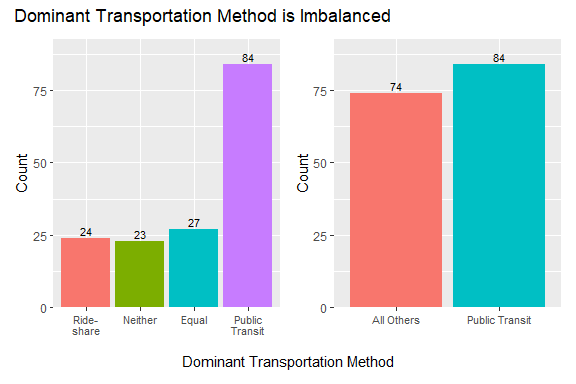

In [ ]:
#| label: transportation_grid
#| fig-width: 6
#| fig-height: 4
library(patchwork)
library(grid)

p1 <- p_all_categories + labs(title = NULL, x = NULL)
p2 <- p_transit_vs_other + labs(title = NULL, x = NULL)

x_label <- wrap_elements(
  full = textGrob("Dominant Transportation Method", gp = gpar(fontsize = 11))
)

(p1 | p2) / x_label +
  plot_layout(heights = c(15, 1)) +
  plot_annotation(title = "Dominant Transportation Method is Imbalanced")